In [39]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import missingno as msno
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
telemetry_df = pd.read_csv('OmniCare_Telemetry_Data.csv')
vitals_df = pd.read_csv('OmniCare_Clinical_Vitals.csv')

patient_df = pd.merge(telemetry_df, vitals_df, on='Patient_ID', how='inner')
print(patient_df.head())

   Patient_ID  High_Deductible_Insurance_Plan  Inpatient_Admission_Rate  \
0        1000                               1                     0.341   
1        1001                               0                     0.213   
2        1002                               0                     0.166   
3        1003                               1                     0.143   
4        1004                               0                     0.219   

   Continuous_Heart_Rate Primary_Diagnosis_Code  Clinic_Capacity_Percentage  \
0                   76.9                J86.381                        0.63   
1                   79.6                M29.789                        0.71   
2                   92.3                E49.618                        0.76   
3                   79.3                E66.244                        0.52   
4                   75.9                J45.553                        0.65   

   Time_of_Day_Index  Procedure_Cost_USD  Height_cm  Weight_kg    BMI  \
0

In [41]:
median_heart_rate = patient_df['Continuous_Heart_Rate'].median()
patient_df['Continuous_Heart_Rate'] = patient_df['Continuous_Heart_Rate'].fillna(median_heart_rate)
missing = patient_df['Continuous_Heart_Rate'].isnull().sum()

print(missing)

0


<Axes: >

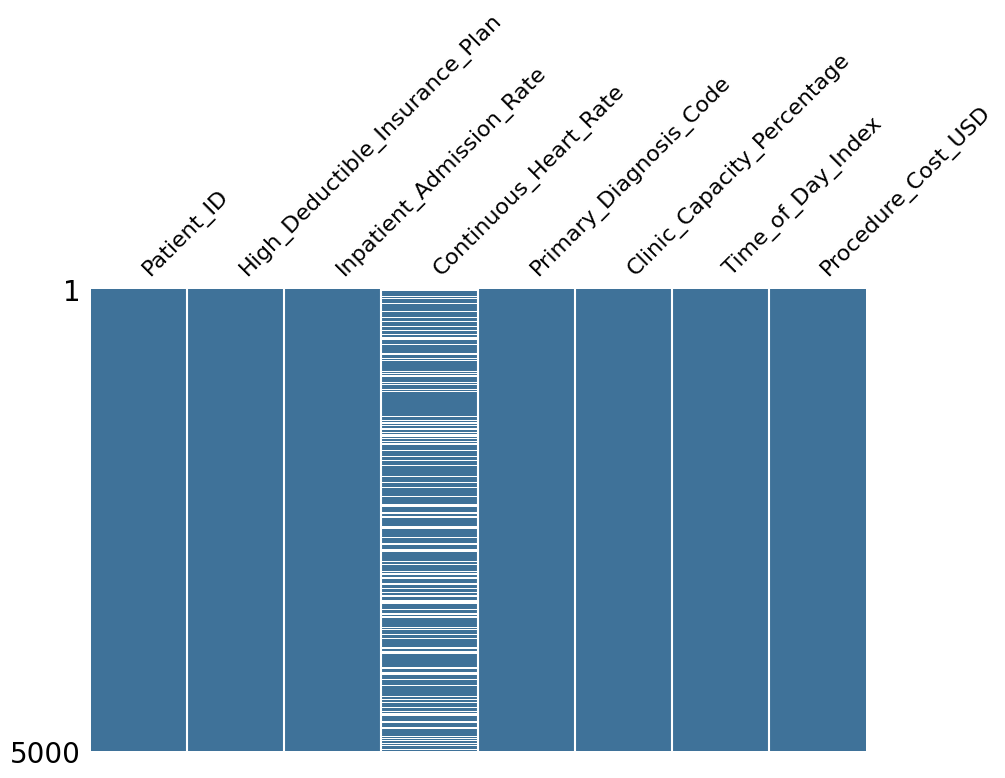

In [42]:
msno.matrix(telemetry_df, figsize=(10, 6), sparkline=False, color=(0.25, 0.45, 0.6))

# I would say this is MNAR because, you would be combining the data of those who are able to afford
# and cannot afford to have their data uploaded. It would remove the data of the lower income patients 
# and skew the data adding a bias into it.

In [43]:
# If you were to turn all of them into binary columns alongside the standard intercept, the columns would add
# up and create redundant data. This overlap breaks the linear regression since we can't determine a solution
# since the variables are exact combinations of each other. To escape the trap we would have to drop one of
# the dummy columns to act as a baseline

In [44]:
encoder = ce.TargetEncoder(cols=['Primary_Diagnosis_Code'])
patient_df['Primary_Diagnosis_Code_Encoded'] = encoder.fit_transform(
    patient_df['Primary_Diagnosis_Code'], 
    patient_df['Procedure_Cost_USD']
)
print(patient_df[['Primary_Diagnosis_Code', 'Primary_Diagnosis_Code_Encoded']].head())

  Primary_Diagnosis_Code  Primary_Diagnosis_Code_Encoded
0                J86.381                     1707.697108
1                M29.789                     1792.303198
2                E49.618                     1730.334968
3                E66.244                     1725.060944
4                J45.553                     1801.821085


In [45]:
formula = (
    "Procedure_Cost_USD ~ Primary_Diagnosis_Code_Encoded + "
    "Clinic_Capacity_Percentage + Time_of_Day_Index + "
    "Continuous_Heart_Rate + Height_cm + Weight_kg + BMI + "
    "Systolic_BP + Diastolic_BP"
)
ols_model = smf.ols(formula=formula, data=patient_df)
ols_results = ols_model.fit()
print(ols_results.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     178.4
Date:                Mon, 30 Mar 2026   Prob (F-statistic):          2.17e-294
Time:                        19:51:28   Log-Likelihood:                -36160.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4990   BIC:                         7.241e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [ ]:
from statsmodels.tools.eval_measures import rmse

y_true = patient_df['Procedure_Cost_USD']
y_pred = ols_results.predict(patient_df)
model_rmse = rmse(y_true, y_pred)
print(model_rmse)

#  If the typical outpatient MRI procedure costs $1,200, and your algorithm generates an RMSE of $450, 
#  explain the catastrophic operational, financial, and regulatory risks of deploying this dynamic pricing 
#  algorithm in a live hospital environment.

# It would cause the prices to become extremely volatile and would cause financial instability, which could 
# lead to the hospital not being able to cover costs such as electricty and overall labor, and could also hurt 
# the hospitals total calculated revenue.

334.6691221159546


<Axes: xlabel='None', ylabel='None'>

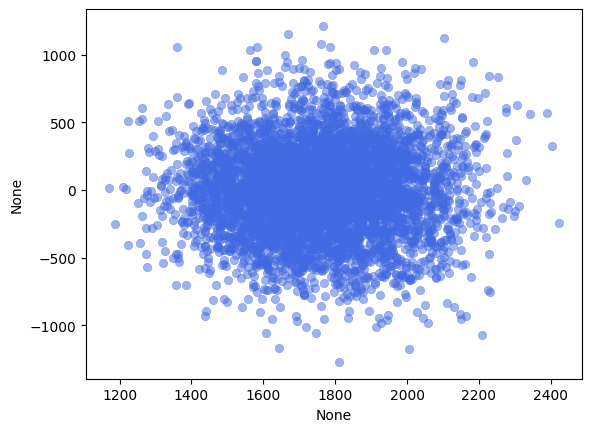

In [ ]:
values = ols_results.fittedvalues
res = ols_results.resid

sns.scatterplot(
    x=values, 
    y=res, 
    alpha=0.5, 
    color='royalblue', 
    edgecolor=None
)

# It shows a consistent spread across the plot and doesn't fan out as the predicted procedure increases.
# The algorithm's reliability is consistent throughout, including peak surge-pricing tiers.

In [48]:
from statsmodels.stats.diagnostic import het_white

# 1. Extract the Residuals and the Design Matrix (Exogenous Variables) 
# from the already fitted OLS model objects.
residuals = ols_results.resid
exog_matrix = ols_model.exog

# 2. Execute White's Lagrange Multiplier Test
white_test_results = het_white(residuals, exog_matrix)

# 3. het_white returns a tuple of 4 values: (LM_Stat, LM_p_value, F_Stat, F_p_value)
lm_stat, lm_pval, f_stat, f_pval = white_test_results

# 4. Display the critical metric
print(f"White's LM Test p-value: {lm_pval}")

White's LM Test p-value: 7.453585958444717e-21
